In [1]:
import numpy as np
import re
from pathlib import Path

data_dir = Path("../results/ft/20260617")
p_values = np.array([0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017, 0.018, 0.019])
L_values = np.array([5, 7, 9, 13, 19])
rep_dirs = sorted(path for path in data_dir.glob("rep*") if path.is_dir())

def load_ft_result(path):
    text = path.read_text()
    ft_match = re.search(r"Ft\s*=\s*\[([^\]]+)\]", text)
    trials_match = re.search(r"trials\s*=\s*\[([^\]]+)\]", text)
    l_match = re.search(r"^L\s*=\s*(\d+)\s*$", text, re.MULTILINE)
    p_match = re.search(r"^p\s*=\s*([0-9.]+)\s*$", text, re.MULTILINE)
    if ft_match is None or trials_match is None or l_match is None or p_match is None:
        raise ValueError(f"Could not parse Ft data from {path}")

    ft = np.fromstring(ft_match.group(1), sep=" ")[0]
    trials = np.fromstring(trials_match.group(1), sep=" ")[0]
    return int(l_match.group(1)), float(p_match.group(1)), ft, trials

Ft_successes = np.zeros((len(L_values), len(p_values)))
Ft_trials = np.zeros_like(Ft_successes)
Ft_rep_count = np.zeros_like(Ft_successes, dtype=int)

for rep_dir in rep_dirs:
    for path in sorted(rep_dir.glob("2d_Ft_*.txt")):
        cur_l, cur_p, ft, trials = load_ft_result(path)
        l_idx = np.where(L_values == cur_l)[0]
        p_idx = np.where(np.isclose(p_values, cur_p))[0]
        if l_idx.size and p_idx.size:
            Ft_successes[l_idx[0], p_idx[0]] += ft * trials
            Ft_trials[l_idx[0], p_idx[0]] += trials
            Ft_rep_count[l_idx[0], p_idx[0]] += 1

if np.any(Ft_rep_count != len(rep_dirs)):
    raise ValueError("Missing Ft replicate data for at least one plotted (L, p) point")

Ft_mean = Ft_successes / Ft_trials
error_rate = 1 - Ft_mean
error_rate_error = np.sqrt(error_rate * (1 - error_rate) / Ft_trials)


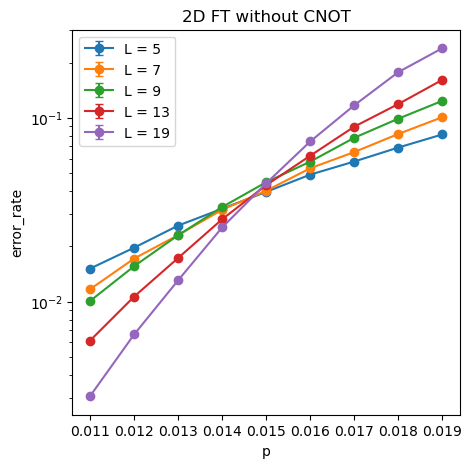

In [3]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.figure(figsize=(5, 5))
for l_idx, cur_l in enumerate(L_values):
    plt.errorbar(p_values, error_rate[l_idx], yerr=error_rate_error[l_idx], fmt="o-", capsize=3, label=f"L = {cur_l}")
    
plt.yscale("log")
plt.xlabel("p")
plt.ylabel("error_rate")
plt.title("2D FT without CNOT")
plt.legend()
plt.show()


In [ ]:
p = np.tile(p_values, len(L_values))
L = np.repeat(L_values, len(p_values))
rate = error_rate.flatten()
rate_error = error_rate_error.flatten()


In [4]:
# Define the model
def model(pL, pc, nu, A, B, C):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu))

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, full_output=True, sigma=rate_error, absolute_sigma=True)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

ValueError: `sigma` has incorrect shape.

In [5]:
# Define the model
def model(pL, pc, nu, A, B, C, D):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu)) + D*((p-pc)**3)*(L**(3/nu))

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, full_output=True, sigma=rate_error, absolute_sigma=True)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 1400.

In [7]:
# Define the model
def model(pL, pc, nu, A, B, C, E, mu):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu)) + E*(L**(-1/mu))

lower_bounds = [-np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, 0]
upper_bounds = [ np.inf,  np.inf,  np.inf,  np.inf,  np.inf,  np.inf, 100]

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, p0=[0.2, 1.5, 0.25, 0, 0, 0, 1], full_output=True, sigma=rate_error, absolute_sigma=True, bounds=(lower_bounds, upper_bounds))

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

Fitted parameters: [ 0.65365671  1.34971846  1.14826578  1.56452687 -5.18613924 -0.34269411
 99.99999043]
Parameter standard deviations: [9.76327070e-03 2.99372267e-01 2.92635434e+02 8.74972246e-02
 3.08466258e+00 2.92607372e+02 8.56792366e+04]


np.float64(22.20382166839723)

In [8]:
# Define the model
def model(pL, pc, nu, A, B, C, D, E, mu):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu)) + D*((p-pc)**3)*(L**(3/nu)) + E*(L**(-1/mu))

lower_bounds = [-np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, 0]
upper_bounds = [ np.inf,  np.inf,  np.inf,  np.inf,  np.inf,  np.inf,  np.inf, 100]

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, p0=[0.2, 1.5, 0.25, 0, 0, 0, 0, 1], full_output=True, sigma=rate_error, absolute_sigma=True, bounds=(lower_bounds, upper_bounds))

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

Fitted parameters: [  0.65404509   1.34448582   1.30804383   1.55235428  -5.36404565
 -21.74404279  -0.50298455  99.99988433]
Parameter standard deviations: [5.69360690e-03 1.77236538e-01 1.68973340e+02 6.08258078e-02
 3.31270470e+00 2.65007526e+01 1.68956754e+02 3.37208319e+04]


np.float64(21.96701507513171)

In [4]:
px = 0.16
w1 = np.log(1/px - 1)
print(w1)

1.6582280766035324
